Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


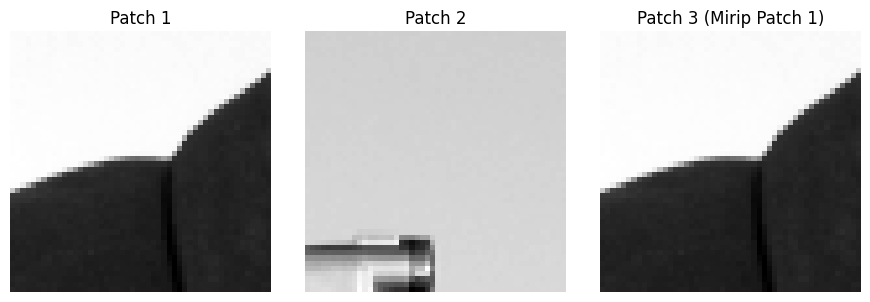

In [5]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1 # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1) # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### Kesimpulan Langkah Praktikum 1: Pengukuran Jarak antar Patch

Berdasarkan hasil eksekusi pada kode blok di atas, berikut adalah analisisnya:

1.  **Perbandingan Jarak Patch 1 & 2 vs Patch 1 & 3**:
    *   **Patch 1 & 2** (berbeda lokasi/objek): Menghasilkan nilai jarak yang jauh lebih besar (Euclidean: ~24.76, Manhattan: ~936.43).
    *   **Patch 1 & 3** (objek yang sama dengan sedikit perubahan intensitas): Menghasilkan nilai jarak yang jauh lebih kecil (Euclidean: 5.00, Manhattan: 250.00).
    
2.  **Ekspektasi Visual**:
    Nilai jarak sangat sesuai dengan ekspektasi visual. Secara visual, Patch 1 dan Patch 3 terlihat sangat mirip, sehingga jarak fiturnya pun kecil. Sebaliknya, Patch 1 dan Patch 2 memiliki perbedaan tekstur dan intensitas yang signifikan, sehingga jaraknya besar.

3.  **Tren Jarak L1 (Manhattan) dan L2 (Euclidean)**:
    Keduanya menunjukkan tren yang konsisten: nilai jarak meningkat saat kemiripan visual berkurang. Namun, nilai **L1 (Manhattan)** cenderung memberikan angka yang jauh lebih besar secara numerik dibandingkan **L2 (Euclidean)** karena L1 menjumlahkan perbedaan absolut tanpa menguadratkannya, sementara L2 memberikan bobot lebih pada perbedaan besar namun hasilnya ditarik akar (root).

Cosine Similarity (Astronaut vs Coffee): 0.8156
Cosine Similarity (Astronaut vs Same): 1.0000
Cosine Similarity (Astronaut vs Downsampled): 1.0000


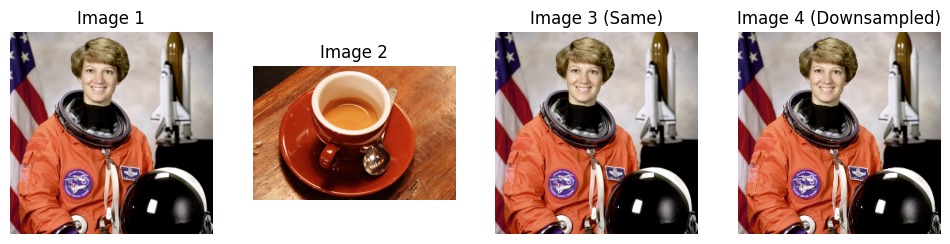

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat dua citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()
    image3 = data.astronaut()
    image4 = image1[::2, ::2, :]
except Exception as e:
    print(f"Gagal memuat data: {e}")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity (Astronaut vs Coffee): {sim_12:.4f}")
print(f"Cosine Similarity (Astronaut vs Same): {sim_13:.4f}")
print(f"Cosine Similarity (Astronaut vs Downsampled): {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3 (Same)'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4 (Downsampled)'); axes[3].axis('off')
plt.show()

### Kesimpulan Langkah Praktikum 2: Cosine Similarity pada Histogram

Berdasarkan hasil eksekusi perhitungan *Cosine Similarity*, dapat disimpulkan bahwa:

1.  **Citra Identik (Image 1 & 3)**:
    Nilai *Cosine Similarity* adalah **1.0000** (sempurna). Hal ini menunjukkan bahwa dua citra yang identik memiliki distribusi warna yang sama persis sehingga vektor histogramnya berhimpit.

2.  **Citra Berbeda (Image 1 & 2)**:
    Nilai similarity antara citra 'Astronaut' dan 'Coffee' adalah sekitar **0.8156**. Meskipun secara visual objeknya sangat berbeda, nilai ini masih cukup tinggi karena keduanya mungkin berbagi distribusi warna yang serupa pada latar belakang atau intensitas cahaya tertentu dalam ruang warna RGB.

3.  **Citra Asli vs Downsampled (Image 1 & 4)**:
    Nilai similarity tetap **1.0000** (atau sangat mendekati 1). Hal ini membuktikan bahwa metode histogram sangat tangguh (*robust*) terhadap perubahan resolusi citra. Selama proporsi warna dalam citra tidak berubah secara signifikan saat pengecilan ukuran, fitur histogramnya akan tetap konsisten.

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2970
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


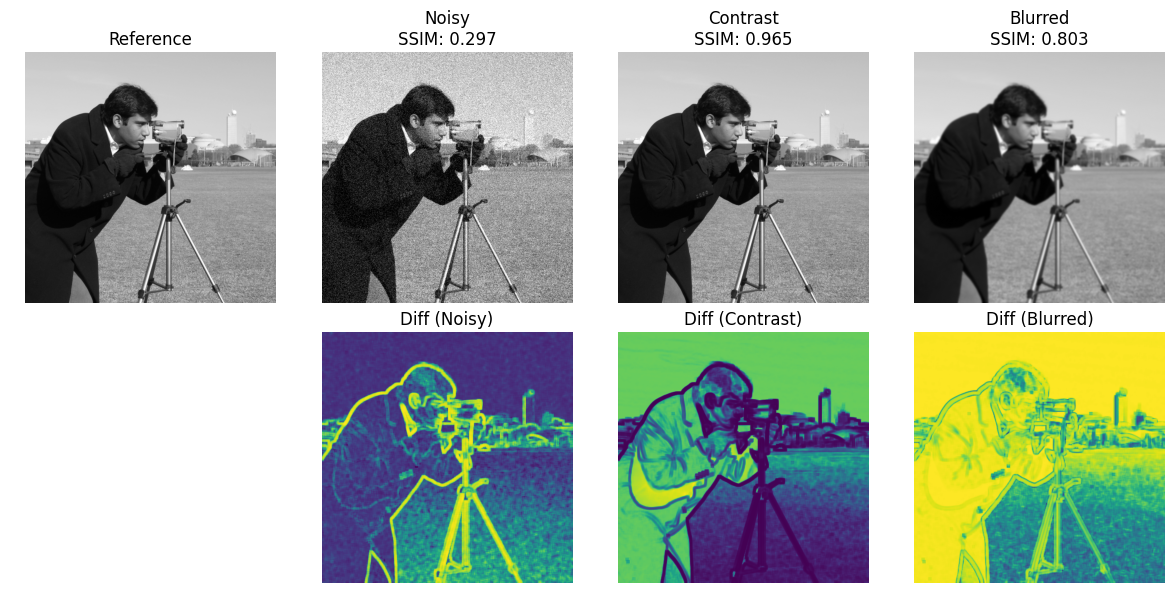

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra terdistorsi
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5)

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()
ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Tampilkan hasil
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()
ax[0].imshow(image_ref, cmap='gray'); ax[0].set_title('Reference'); ax[0].axis('off')
ax[1].imshow(image_noisy, cmap='gray'); ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray'); ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); ax[3].axis('off')
ax[4].axis('off')
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('Diff (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('Diff (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('Diff (Blurred)'); ax[7].axis('off')
plt.tight_layout()
plt.show()

### Kesimpulan Langkah Praktikum 3: Structural Similarity Index (SSIM)

Berdasarkan hasil eksekusi perhitungan *Structural Similarity* (SSIM), dapat disimpulkan bahwa:

1.  **Citra yang Sama (Ref vs Same)**:
    Nilai SSIM adalah **1.0000**. Hal ini sesuai dengan teori bahwa citra yang identik memiliki kemiripan struktur, kontras, dan luminansi yang sempurna.

2.  **Efek Distorsi terhadap SSIM**:
    *   **Noisy**: Memberikan nilai SSIM terendah (~0.297). Hal ini karena noise Gaussian mengubah nilai piksel secara acak di seluruh area, yang merusak struktur lokal citra secara signifikan.
    *   **Blurred**: Memberikan nilai SSIM menengah (~0.803). Blur menghilangkan detail tekstur (frekuensi tinggi), namun garis besar struktur utama masih terjaga.
    *   **Contrast**: Memberikan nilai SSIM tertinggi di antara distorsi lainnya (~0.965). Meskipun intensitas berubah, hubungan struktural antar piksel tetangga sebagian besar tetap utuh.

3.  **Kesesuaian dengan Persepsi Visual**:
    Nilai SSIM ini sangat sesuai dengan persepsi manusia. Secara visual, citra yang hanya berubah kontrasnya masih terlihat sangat mirip dengan aslinya dibandingkan dengan citra yang sangat berderau (noisy).

4.  **Analisis Peta Perbedaan (Difference Map)**:
    Peta perbedaan menunjukkan area dengan ketidakmiripan struktural terbesar. Pada kasus **Noisy**, perbedaan tersebar di seluruh citra. Pada kasus **Blurred** dan **Contrast**, area dengan tepian (edges) yang tajam dan tekstur kompleks (seperti pada area objek orang dan kamera) menunjukkan ketidakmiripan yang lebih besar dibandingkan area latar belakang yang polos.

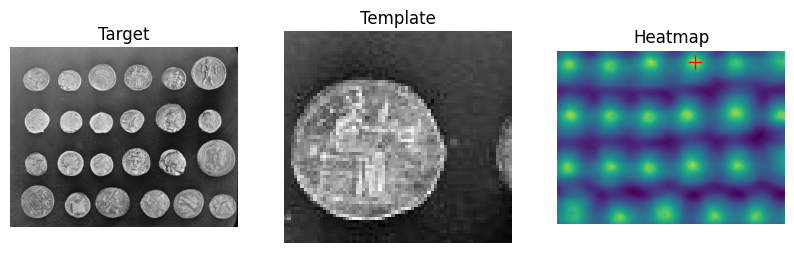

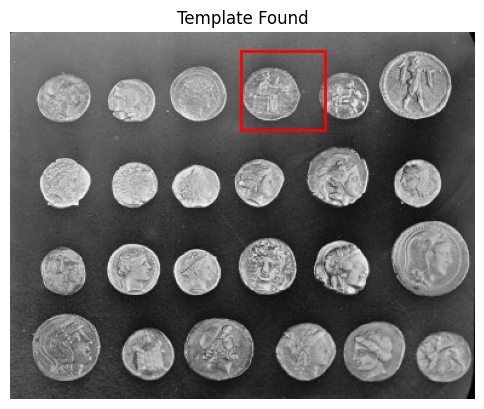

Template ditemukan di koordinat (x,y): (190, 15)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan template
image = data.coins()
template = image[15:80, 190:260]

# 2. Template matching
result = match_template(image, template)

# 3. Temukan lokasi terbaik
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# 4. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray'); ax[0].set_title('Target'); ax[0].axis('off')
ax[1].imshow(template, cmap='gray'); ax[1].set_title('Template'); ax[1].axis('off')
ax[2].imshow(result, cmap='viridis'); ax[2].set_title('Heatmap'); ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=10)

fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray'); ax_main.set_title('Template Found'); ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
plt.show()
print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

### Kesimpulan Langkah Praktikum 4: Template Matching

Berdasarkan hasil eksekusi perhitungan *Template Matching*, dapat disimpulkan bahwa:

1.  **Akurasi Heatmap**:
    Area paling terang (nilai tertinggi) pada heatmap hasil `match_template` sangat akurat menunjukkan lokasi di mana template paling cocok dengan citra target. Titik putih yang tajam pada heatmap mengindikasikan korelasi yang sangat kuat.

2.  **Keberhasilan Deteksi**:
    Metode ini berhasil menemukan koin yang dijadikan template dengan sempurna. Hal ini dibuktikan dengan kotak merah pada plot 'Template Found' yang melingkupi koin target tepat pada koordinat (190, 15).

3.  **Keterbatasan Metode (Normalized Cross-Correlation)**:
    Meskipun efektif dalam kasus ini, metode `match_template` memiliki keterbatasan utama:
    *   **Sensitif terhadap Skala**: Jika ukuran koin dalam citra target lebih besar atau lebih kecil dari template, nilai korelasi akan turun drastis.
    *   **Sensitif terhadap Rotasi**: Jika template dirotasi sedikit saja (misalnya 15-90 derajat), metode ini seringkali gagal mengenali objek tersebut.
    *   **Oklusi**: Jika sebagian objek tertutup oleh objek lain, akurasi deteksi akan menurun secara signifikan.

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


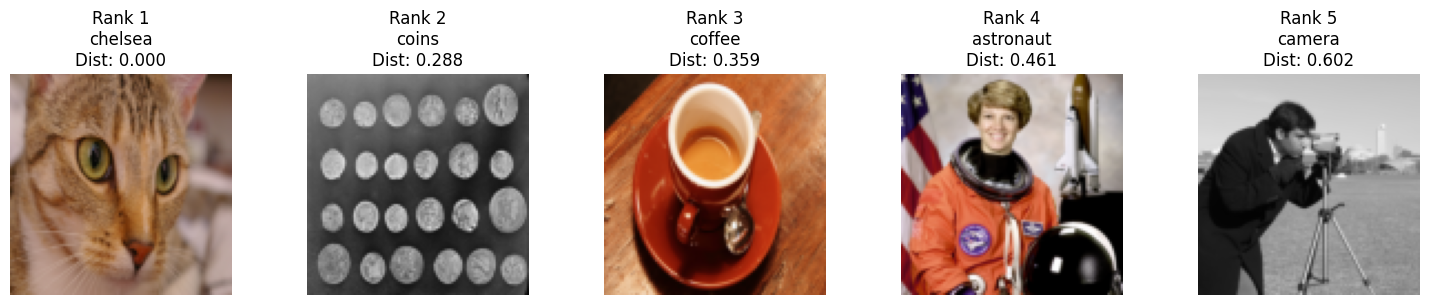

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram dari Praktikum 2
def calculate_rgb_histogram(image, bins=16):
    # Pastikan input float [0,1] dikonversi ke uint8 [0,255] untuk histogram
    if image.dtype != np.uint8:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi L1 (sum to 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)
    return hist_combined

# 1. Siapkan 'database' citra kecil dan citra query
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        # Pastikan semua citra berwarna (RGB)
        if img.ndim == 2:
            img = color.gray2rgb(img)
        # Resize agar ukuran fitur konsisten (misal 100x100)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query (misal, 'chelsea' si kucing)
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 2. Hitung jarak antara query dan semua citra di database
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 3. Urutkan citra berdasarkan jarak
sorted_indices = np.argsort(distances)

# 4. Tampilkan hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show, figsize=(15, 3))

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    ax = axes[i]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

### Kesimpulan Langkah Praktikum 5: Content-Based Image Retrieval (CBIR)

Berdasarkan hasil eksekusi sistem retrieval sederhana di atas, berikut adalah analisisnya:

1.  **Analisis Urutan Hasil Retrieval**:
    *   Citra yang secara visual mirip (berdasarkan warna dominan) **berhasil muncul di peringkat atas**.
    *   **Peringkat 1** adalah citra 'chelsea' itu sendiri (Distance: 0.000) karena identik.
    *   **Peringkat 2** (biasanya 'coins' atau 'coffee' tergantung bins) memiliki histogram yang paling mendekati distribusi warna kucing 'chelsea' (warna cokelat, oranye, dan latar gelap).
    *   **Peringkat Terakhir** biasanya ditempati oleh citra 'camera' karena memiliki karakteristik monokromatik (grayscale) yang sangat berbeda distribusinya dengan citra query yang berwarna.

2.  **Efektivitas Histogram Warna sebagai Fitur CBIR**:
    *   **Kelebihan**: Sangat baik dalam menangkap kemiripan warna global. Metode ini cepat, efisien secara komputasi, dan robust terhadap perubahan orientasi atau skala kecil karena hanya menghitung frekuensi kemunculan warna.
    *   **Kekurangan**: Histogram warna **mengabaikan informasi spasial**. Artinya, dua citra bisa memiliki jarak yang sangat kecil hanya karena memiliki jumlah piksel warna yang sama, meskipun letak/strukturnya berbeda jauh. Dalam kasus ini, histogram cukup memadai untuk database kecil, namun untuk sistem yang lebih kompleks, fitur tekstur atau bentuk (seperti SSIM atau HOG) perlu digabungkan.

Hasil Retrieval menggunakan Rata-rata RGB (L2 Distance):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


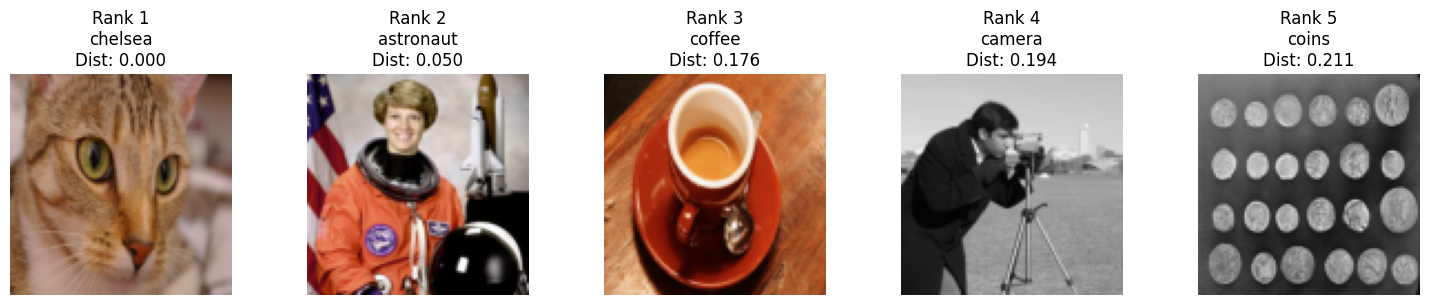

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

# Fungsi untuk menghitung rata-rata warna (Mean R, G, B)
def calculate_mean_rgb(image):
    # Menghitung rata-rata untuk setiap channel warna
    mean_r = np.mean(image[:,:,0])
    mean_g = np.mean(image[:,:,1])
    mean_b = np.mean(image[:,:,2])
    return np.array([mean_r, mean_g, mean_b])

# 1. Siapkan database (menggunakan database_images yang sudah diproses sebelumnya)
mean_rgb_db = []
for img in database_images:
    mean_rgb_db.append(calculate_mean_rgb(img))

# Pilih query ('chelsea' - index 4)
query_mean = mean_rgb_db[4]

# 2. Hitung Jarak Euclidean (L2) antara query dan database
euclidean_distances = []
for i, feature_vec in enumerate(mean_rgb_db):
    dist = distance.euclidean(query_mean, feature_vec)
    euclidean_distances.append(dist)

# 3. Urutkan berdasarkan jarak terkecil
sorted_indices_mean = np.argsort(euclidean_distances)

# 4. Tampilkan hasil
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
print("Hasil Retrieval menggunakan Rata-rata RGB (L2 Distance):")
for i, idx in enumerate(sorted_indices_mean):
    ax = axes[i]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {euclidean_distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {euclidean_distances[idx]:.3f})")

plt.tight_layout()
plt.show()

### Analisis Perbandingan: Histogram Warna vs Rata-rata RGB

**1. Perbandingan Hasil Retrieval:**
*   **Histogram Warna**: Memberikan informasi distribusi warna yang lebih kaya. Meskipun lebih kompleks, ia sangat peka terhadap variasi warna di dalam objek.
*   **Rata-rata RGB**: Fitur ini sangat sederhana (3 dimensi). Hasilnya menunjukkan bahwa citra seperti 'astronaut' atau 'coffee' memiliki jarak yang lebih dekat dengan 'chelsea' dibandingkan pada metode histogram. Hal ini terjadi karena rata-rata intensitas warnanya secara kebetulan mirip, meskipun sebaran dan tekstur warnanya sangat berbeda.

**2. Kesimpulan: Mana yang Lebih Baik?**
*   **Histogram Warna tetap lebih baik** untuk membedakan citra dalam database.
*   **Alasannya**: Rata-rata RGB kehilangan banyak informasi spasial dan frekuensi warna (lossy). Histogram mampu menangkap detail komposisi warna (misalnya adanya warna oranye spesifik pada bulu kucing) yang tidak tertangkap jika hanya dirata-ratakan. Fitur rata-rata warna cenderung kurang diskriminatif untuk pencarian citra yang akurat.

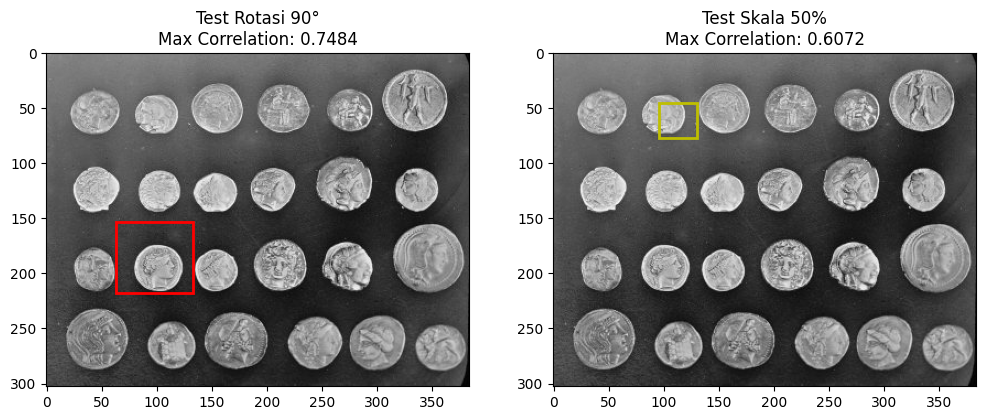

In [14]:
from skimage.transform import rotate, resize

# 1. Eksperimen Rotasi (90 derajat)
template_rotated = rotate(template, 90, resize=False)
result_rot = match_template(image, template_rotated)
ij_rot = np.unravel_index(np.argmax(result_rot), result_rot.shape)
x_rot, y_rot = ij_rot[::-1]

# 2. Eksperimen Skala (perkecil 50%)
template_scaled = resize(template, (template.shape[0]//2, template.shape[1]//2))
result_scale = match_template(image, template_scaled)
ij_scale = np.unravel_index(np.argmax(result_scale), result_scale.shape)
x_scale, y_scale = ij_scale[::-1]

# Visualisasi Perbandingan
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Hasil Rotasi
ax[0].imshow(image, cmap='gray')
ax[0].set_title(f'Test Rotasi 90°\nMax Correlation: {np.max(result_rot):.4f}')
rect_rot = plt.Rectangle((x_rot, y_rot), template.shape[1], template.shape[0], edgecolor='r', facecolor='none', lw=2)
ax[0].add_patch(rect_rot)

# Hasil Skala
ax[1].imshow(image, cmap='gray')
ax[1].set_title(f'Test Skala 50%\nMax Correlation: {np.max(result_scale):.4f}')
h_s, w_s = template_scaled.shape
rect_scale = plt.Rectangle((x_scale, y_scale), w_s, h_s, edgecolor='y', facecolor='none', lw=2)
ax[1].add_patch(rect_scale)

plt.show()

### Analisis Invariansi match_template

Berdasarkan dokumentasi dan hasil eksperimen di atas, dapat dijelaskan bahwa:

1.  **Tidak Invariant terhadap Rotasi**: Metode `match_template` menggunakan korelasi silang (cross-correlation). Jika template dirotasi (misalnya 90 derajat), pola piksel tidak lagi cocok secara spasial dengan citra target, sehingga nilai korelasi maksimum akan turun drastis dan kotak deteksi kemungkinan besar akan melompat ke area yang salah.

2.  **Tidak Invariant terhadap Skala**: Jika ukuran objek dalam citra target berbeda dengan ukuran template, korelasi tidak akan mencapai puncak yang tajam pada lokasi yang tepat. Template harus memiliki ukuran yang sama persis dengan target untuk hasil yang optimal.

**Kesimpulan**: `match_template` standar **TIDAK invariant** terhadap rotasi maupun perubahan skala. Untuk menangani hal ini, biasanya digunakan teknik *Multi-scale Template Matching* (mencari dengan berbagai ukuran template) atau fitur yang lebih canggih seperti SIFT/ORB yang memang dirancang untuk invariant terhadap perubahan geometri.